In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import scipy as sy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

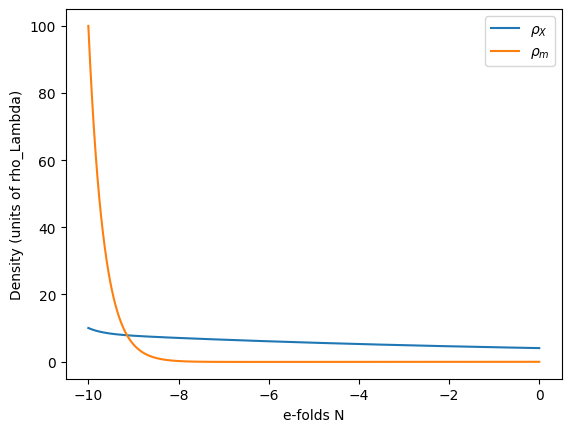

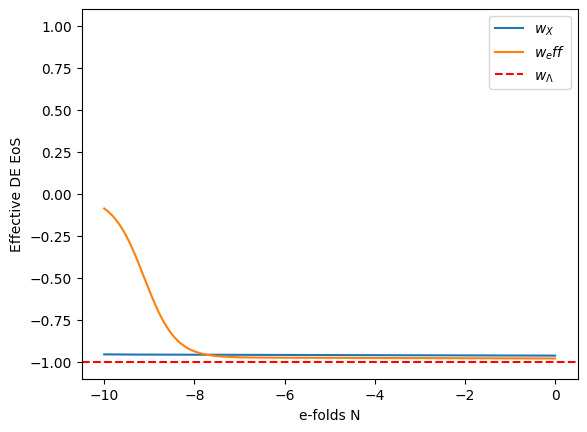

In [3]:
# Parameters to be optimised to lambda cdm data
w = -0.95
q = 0.05


def system(N, vars):
    x, y = vars

    w_x = w - (1 + w)/(x+1e-8)
    
    dx =-3*(1+w)*(x-1) + q*(x-y)
    dy =-3*y - q*(x-y)

    return [dx, dy]

N = np.linspace(-10, 0, 500) # -50 epochs is around the time of inflation but for observational data fitting i need to start today slightly back -10-0 epochs
sol = solve_ivp(system, [-10,0], [10,100] , t_eval=N)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
#large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
a = np.exp(sol.t)  # scale factor


rho_X = x * 1  # assuming rho_Lambda = 1 in code units
rho_m = y * 1
rho_tot = rho_X + rho_m + 1
w_x = w - (1 + w)/(x+1e-8)
w_eff = (w*(x-1)-1) /(x+y)

plt.figure()
plt.plot(N, x, label=r'$\rho_X$')
plt.plot(N, y, label=r'$\rho_m$')
plt.xlabel('e-folds N')
plt.ylabel('Density (units of rho_Lambda)')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(N, w_x, label=r'$w_X$')
plt.plot(N, w_eff, label=r'$w_eff$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

Physical fixed points: [[1.0350877192982457, -0.017543859649122806]]
Fixed points (1.0350877192982457,-0.017543859649122806)
Eigen Values: [-1.44833518 -2.95166482]
Type=node
Stability=Attractor



/tmp/ipykernel_2306/90627675.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


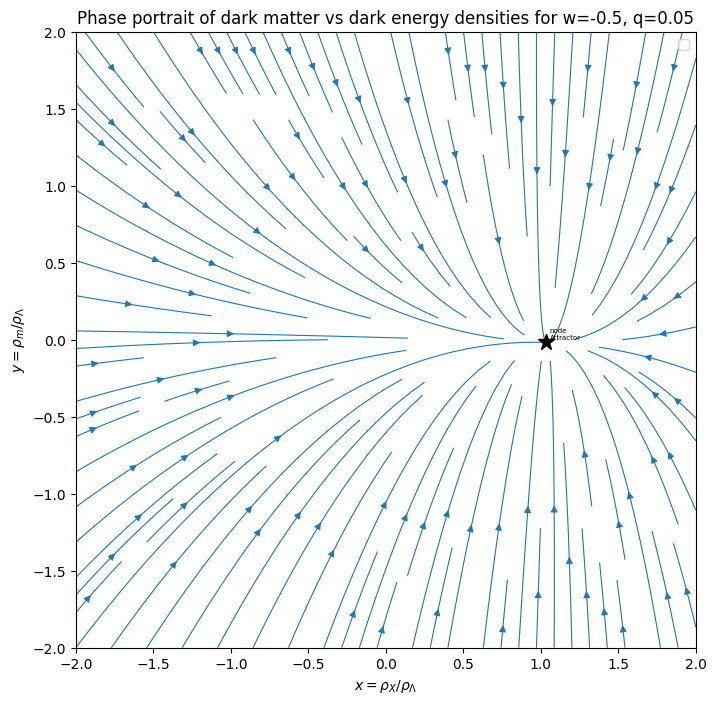

In [4]:
#plotting phase portrait at lambda slice
def phase_plot(w, q):
  def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
  initialState=np.array([10, 100])

  simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

  def stop_event(t, y):
      x, y_ = y
      return abs(x) - 1e-6  # stop near singularity

  stop_event.terminal = True

  sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
  dx = sol.y[0]
  dy = sol.y[1]
  a = np.exp(sol.t)  # scale factor

  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-2,2,10)
  x1 = np.linspace(-2,2,10)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
              dx,dy= system(0,[X0[i,j], X1[i,j]])
              dX0[i,j] = dx
              dX1[i,j] = dy

# in order to plot trajectories of solutions from fixed points, using sympy to solve the equations dx and dy =0 and 
# finding values of x and y. These can then be used in a jaconian matrix to determine eigenvalues at these fixed points which 
# determines stability.  

  x_FP, y_FP = sp.symbols('x y ', real=True)

  #w_x = w_a - (1 + w_a)/x_FP
  f =-3*(1+w)*(x_FP-1) + q*(x_FP-y_FP)
  g =-3*y_FP - q*(x_FP-y_FP)
  J_sym = sp.Matrix([f, g]).jacobian([x_FP, y_FP]) # Symbolic Jacobian for x and y 2D

  solutions = sp.solve([f, g], [x_FP, y_FP], dict=True)
  FP=[]
  for sol in solutions:
    if x_FP in sol and y_FP in sol:
      x_val = sol[x_FP]
      y_val = sol[y_FP]
      #z_val = sol[z_FP]
      #lam_val = sol[lam_FP]
      if x_val.is_real and y_val.is_real:
          x_val,y_val = float(x_val),float(y_val)
          FP.append([float(x_val),float(y_val)])
  print("Physical fixed points:", FP)

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.2, linewidth=0.8)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')


# classifying E vals in accordance with dynamical system analysis
  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

# plotting the fixed points by determining their eigenvalues and then classifying them using the above function
  for fp in FP:
    x_c, y_c = fp
    J_num = np.array(J_sym.subs({x_FP: x_c,y_FP: y_c}),dtype=float)
    eigvals,eigvecs = np.linalg.eig(J_num)
    stability,point_type = classify_FP(eigvals)
    print(f'Fixed points ({x_c:},{y_c})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12)
    plt.text(x_c+0.02, y_c+0.02, f"{point_type}\n{stability}", fontsize=5)

# a separatrix is plotted from a saddle point and divides areas of different dynamics along the eigenvector direction


    if stability=='saddle': 
       delta=1e-5 # small perturbations along eigenvector
       for vector,value in zip(eigvecs.T,eigvals):
          if value>0:
             for pm in [-1,1]: #either positive of negative direction
              x_start = np.array([x_c,y_c])+pm*delta*vector[:2]
              trajectory= solve_ivp(fun=system,t_span=(simulationTime[0], simulationTime[-1]),y0=x_start,t_eval=simulationTime,method='RK45',events=stop_event)
              plt.plot(trajectory.y[0],trajectory.y[1],'r--',linewidth=1)
    

  plt.xlabel(r"$x = \rho_X/ \rho_\Lambda$")
  plt.ylabel(r"$y=\rho_m/ \rho_\Lambda$")
  plt.title(rf"Phase portrait of dark matter vs dark energy densities for w={w}, q={q}")
  #plt.xlim(-1.5,1.5)
  #plt.ylim(-1.5,1.5)
  plt.legend()
  plt.show()





# try w=-0.95 and -0.5 and q=+- 0.05
phase_plot(-0.5,0.05)

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018/meta


#### Plot of x vs y vs $w_{eff}$

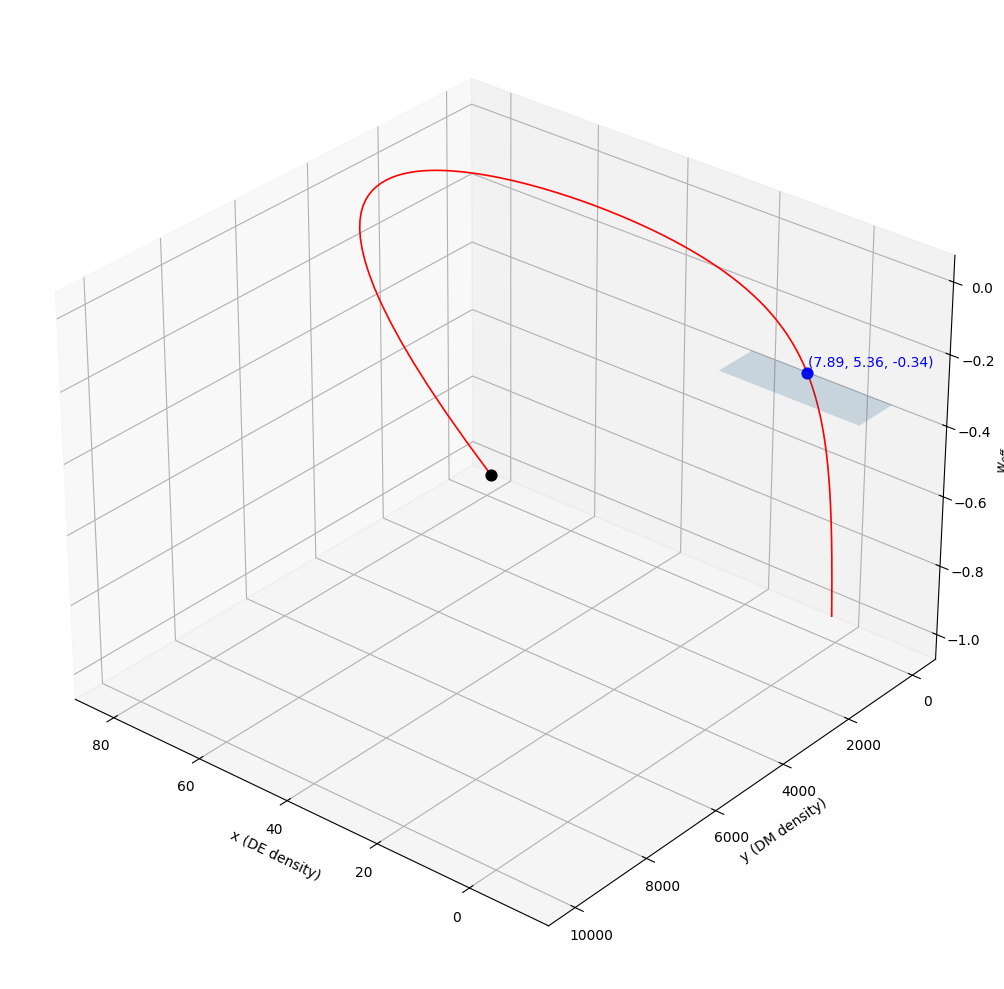

In [25]:
w,q=-0.5,-0.05



def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
initialState=np.array([1, 10000]) # x~1   y=y0e^-3N~1e13

simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
weff=((w*(x-1)-1)/(x+y))

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(x, y, weff, color='r', lw=1.2)
ax.scatter3D(x[0], y[0], weff[0], color='black', s=60)

a = np.linspace(-10, 20, 100)
b = np.linspace(-10, 1000, 10000)
X, Y = np.meshgrid(a, b)
Z = np.ones(X.shape) * -1/3
ax.plot_surface(X, Y, Z, alpha=0.2)

idx = np.where(np.isclose(weff, -1/3, atol=3e-3))[0]
for i in idx:
    ax.scatter3D(x[i], y[i], weff[i], color='blue', s=60)
    ax.text(x[i]+0.02, y[i]+0.02, weff[i]+0.02, f"({x[i]:.2f}, {y[i]:.2f}, {weff[i]:.2f})", color='b')

      

ax.set_xlabel("x (DE density)")
ax.set_ylabel("y (DM density)")
ax.set_zlabel("$w_{eff}$")
ax.view_init(elev=30, azim=130)
plt.tight_layout()
plt.show()